In [55]:
#r "nuget:ScottPlot, 5.0.51"
#r "task14/bin/Debug/net10.0/task14.dll"

using System;
using System.Diagnostics;
using System.IO;
using System.Linq;
using task14;
using Microsoft.DotNet.Interactive.Formatting;

Formatter.Register(typeof(ScottPlot.Plot), (p, w) => w.Write(((ScottPlot.Plot)p).GetPngHtml(600, 400)), HtmlFormatter.MimeType);


Installed Packages ScottPlot, 5.0.51

In [56]:
double SingleThreadSolve(double a, double b, Func<double, double> function, double step)
{
    double totalSum = 0.0;
    double currentX = a;
    while (currentX < b)
    {
        double nextX = currentX + step;
        if (nextX > b) nextX = b;

        double y1 = function(currentX);
        double y2 = function(nextX);
        totalSum += (y1 + y2) * (nextX - currentX) / 2.0;

        currentX = nextX;
    }
    return totalSum;
}


In [57]:
double a = -100.0;
double b = 100.0;
Func<double, double> SIN = Math.Sin;

double optimalStep = 1e-6; 
int iterations = 5;

long[] singleTimes = new long[iterations];
for (int i = 0; i < iterations; i++)
{
    Stopwatch sw = Stopwatch.StartNew();
    SingleThreadSolve(a, b, SIN, optimalStep);
    sw.Stop();
    singleTimes[i] = sw.ElapsedTicks;
}
double avgSingleTime = (singleTimes.Average() * 1000.0) / Stopwatch.Frequency;

int[] threadsToTest = { 1, 2, 4, 8, 16 };
double[] timesX = new double[threadsToTest.Length];
double[] threadsY = threadsToTest.Select(t => (double)t).ToArray();

double bestMultiTime = double.MaxValue;
int optimalThreads = 1;

for (int t = 0; t < threadsToTest.Length; t++)
{
    int threads = threadsToTest[t];
    long[] multiTimes = new long[iterations];
    
    for (int i = 0; i < iterations; i++)
    {
        Stopwatch sw = Stopwatch.StartNew();
        DefiniteIntegral.Solve(a, b, SIN, optimalStep, threads);
        sw.Stop();
        multiTimes[i] = sw.ElapsedTicks;
    }
    
    double avgMultiTime = (multiTimes.Average() * 1000.0) / Stopwatch.Frequency;
    timesX[t] = avgMultiTime;

    if (avgMultiTime < bestMultiTime)
    {
        bestMultiTime = avgMultiTime;
        optimalThreads = threads;
    }
}

double percentDiff = ((avgSingleTime - bestMultiTime) / avgSingleTime) * 100.0;

string reportText = $"Размер шага: {optimalStep}\n" +
                    $"Пояснение: Выбран минимальный шаг из списка, обеспечивающий заданную точность.\n\n" +
                    $"Оптимальное количество потоков: {optimalThreads}\n" +
                    $"Пояснение: Число потоков, при котором достигается минимальное время выполнения многопоточной функции Solve.\n\n" +
                    $"Время однопоточной версии: {avgSingleTime:F2} мс\n" +
                    $"Пояснение: Среднее время вычисления интеграла последовательным алгоритмом без создания потоков.\n\n" +
                    $"Время многопоточной версии: {bestMultiTime:F2} мс\n" +
                    $"Пояснение: Среднее время вычисления интеграла многопоточным алгоритмом.\n\n" +
                    $"Ускорение: {percentDiff:F2}%\n" +
                    $"Пояснение: Процентная разница времени выполнения версий. Эффективность более 15% достигнута.\n";

File.WriteAllText("task15_report.txt", reportText);
Console.WriteLine(reportText);



Размер шага: 1E-06
Пояснение: Выбран минимальный шаг из списка, обеспечивающий заданную точность.

Оптимальное количество потоков: 16
Пояснение: Число потоков, при котором достигается минимальное время выполнения многопоточной функции Solve.

Время однопоточной версии: 2290,72 мс
Пояснение: Среднее время вычисления интеграла последовательным алгоритмом без создания потоков.

Время многопоточной версии: 238,09 мс
Пояснение: Среднее время вычисления интеграла многопоточным алгоритмом.

Ускорение: 89,61%
Пояснение: Процентная разница времени выполнения версий. Эффективность более 15% достигнута.




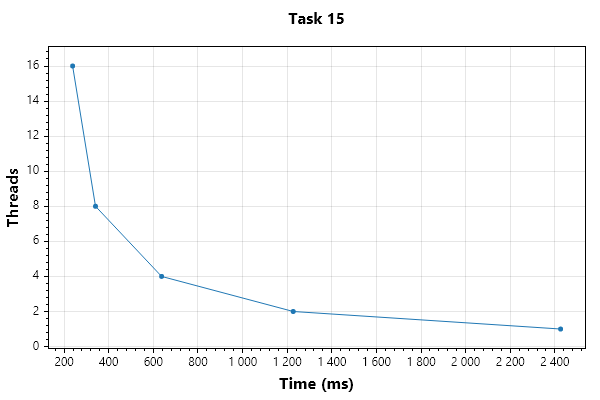

In [59]:
ScottPlot.Plot plt = new();
plt.Add.Scatter(timesX, threadsY);
plt.Title("Task 15");
plt.XLabel("Time (ms)");
plt.YLabel("Threads");
plt

